# A Brief Introdiction to Neural Networks

This short practical is an introduction to neural networks that shows how they can be used for regression and classification tasks.

First, as usual, we'll load some useful libraries.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import sklearn.datasets as skd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier, MLPRegressor


We will load a simple dataset from Seaborn which shows examples of bills from diners in a restaurant, and the tips that were left.

In [18]:
# Load tips dataset
tips = sns.load_dataset("tips")
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


For the purposes of this exercise, we'll focus on the first two columns of this table, which contain numeric values.

In [6]:
tips.iloc[:,0:2]

,total_bill,tip
0,16.99,1.01
1,10.34,1.66
2,21.01,3.50
3,23.68,3.31
4,24.59,3.61
...,...,...
239,29.03,5.92
240,27.18,2.00
241,22.67,2.00
242,17.82,1.75


# 1. Neural networks for regression

Let's first fit a linear regression model to this data.

In [7]:
X_tips = tips.iloc[:, 0:1]  
y_tips = tips.iloc[:, 1]    


lr = LinearRegression()
lr.fit(X_tips, y_tips)

print("LINEAR REGRESSION")
print("-----------------")
print("Intercept:", lr.intercept_)
print("Slope:", lr.coef_[0])

LINEAR REGRESSION
-----------------
Intercept: 0.9202696135546731
Slope: 0.10502451738435337


Now let's fit Neural Network without hidden layers and identity activation function (linear equivalence)

In [10]:
nn_reg = MLPRegressor(
    hidden_layer_sizes=(),  # no hidden layer. equivalent to linear regression
    activation="identity", # this is identity function of b+w*x . equivalent to linear regression
    solver="lbfgs",
    max_iter=5000,
    random_state=1,
)
nn_reg.fit(X_tips, y_tips)

print("\nNEURAL NETWORK (0 hidden layers)")
print("--------------------------------")
print("Bias:", nn_reg.intercepts_[0][0])
print("Weight:", nn_reg.coefs_[0][0, 0])


NEURAL NETWORK (0 hidden layers)
--------------------------------
Bias: 0.9202696243447809
Weight: 0.10502451683901129


We can now get and compare the fitted values of both

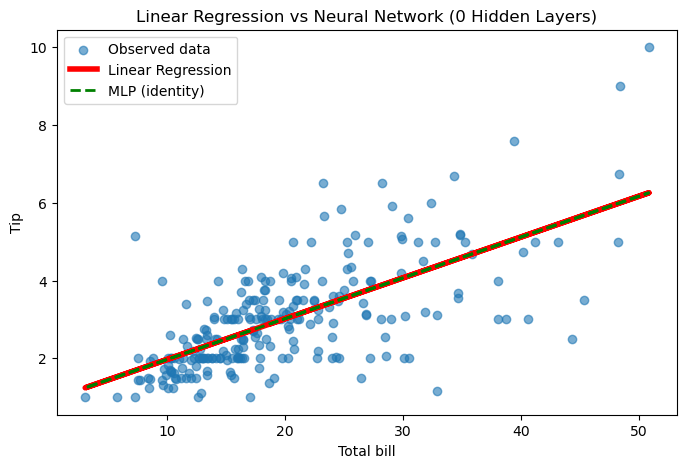

In [11]:
plt.figure(figsize=(8, 5))

plt.scatter(X_tips, y_tips, label="Observed data", alpha=0.6)
plt.plot(X_tips, lr.predict(X_tips), linewidth=4, label="Linear Regression", color="red")
plt.plot(X_tips, nn_reg.predict(X_tips), "--", linewidth=2, label="MLP (identity)", color="green")
plt.xlabel("Total bill")
plt.ylabel("Tip")
plt.title("Linear Regression vs Neural Network (0 Hidden Layers)")
plt.legend()
plt.show()

Let us now fit mutilayer neural network, i.e, fit a neural network with hidden layers and look at the predictions against the true values

In [54]:
# Here we define our models architecture
nn_reg2 = MLPRegressor(hidden_layer_sizes=(3,2), random_state=1, max_iter=2000)
# ...and here we train the model
nn_reg2.fit(X_tips, y_tips)


,"loss loss: {'squared_error', 'poisson'}, default='squared_error'The loss function to use when training the weights. Note that the""squared error"" and ""poisson"" losses actually implement""half squares error"" and ""half poisson deviance"" to simplify thecomputation of the gradient. Furthermore, the ""poisson"" loss internally usesa log-link (exponential as the output activation function) and requires``y >= 0``... versionchanged:: 1.7 Added parameter `loss` and option 'poisson'.",'squared_error'
,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(3, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the regressor will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate ``learning_rate_`` at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when solver='sgd'.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",2000
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True


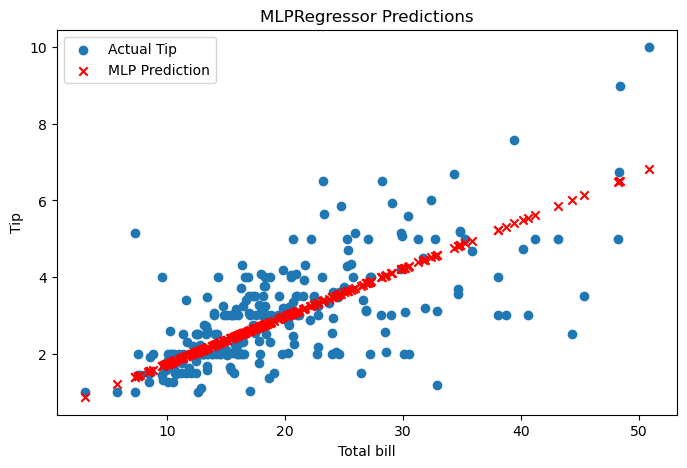

In [55]:
ypred = nn_reg2.predict(X_tips)
plt.figure(figsize=(8, 5))
plt.scatter(X_tips, y_tips, label="Actual Tip")
plt.scatter(X_tips, ypred, color="red", marker="x", label="MLP Prediction")
plt.xlabel("Total bill")
plt.ylabel("Tip")
plt.title("MLPRegressor Predictions")
plt.legend()
plt.show()

You can explore changing the `random_state` and the number of nodes in each layer (`hidden_layer_sizes`) or, indeed, the number of layers. You will probably see that the model doesn't always find a straight line fit. The larger number of parameters and the non-linear activation function allow more varied models.

# 2. Network Architecture Metadata

Let's use the multilayer neural network we just fitted to see how we can access information about the architecture of the network through the fitted object. You can see all the information you can extract by running:

In [56]:
?MLPRegressor

Init signature:
MLPRegressor(
    loss='squared_error',
    hidden_layer_sizes=(100,),
    activation='relu',
    *,
    solver='adam',
    alpha=0.0001,
    batch_size='auto',
    learning_rate='constant',
    learning_rate_init=0.001,
    power_t=0.5,
    max_iter=200,
    shuffle=True,
    random_state=None,
    tol=0.0001,
    verbose=False,
    warm_start=False,
    momentum=0.9,
    nesterovs_momentum=True,
    early_stopping=False,
    validation_fraction=0.1,
    beta_1=0.9,
    beta_2=0.999,
    epsilon=1e-08,
    n_iter_no_change=10,
    max_fun=15000,
)
Docstring:     
Multi-layer Perceptron regressor.

This model optimizes the squared error using LBFGS or stochastic gradient
descent.

.. versionadded:: 0.18

Parameters
----------
loss : {'squared_error', 'poisson'}, default='squared_error'
    The loss function to use when training the weights. Note that the
    "squared error" and "poisson" losses actually implement
    "half squares error" and "half poisson deviance" to s

Try extracting the coefficients or weights of the fitted model nn_reg2

In [57]:
nn_reg2.coefs_

[array([[-0.03720901,  0.73758991, -0.9706217 ]]),
 array([[-0.44787575, -0.13235054],
        [-0.0506213 ,  0.25330614],
        [-0.02396001,  0.18896776]]),
 array([[-1.08137205],
        [ 0.66846844]])]

Here is a description of the fitted nn_reg2 neural network example:

In [58]:
print(f"The network has {nn_reg2.n_layers_} layers (including input and output layers).")
print("   ")
print(f"The sizes of the hidden layers are {nn_reg2.hidden_layer_sizes}.")
print("   ")
print(f"The activation function of the hidden layers is {nn_reg2.activation}")
print("   ")
print(f"The activation function of the output layer is {nn_reg2.out_activation_}")
print("   ")
print(f"This network takes as input {nn_reg2.n_features_in_} feature and this is {nn_reg2.feature_names_in_}")
print("   ")
print(f"The starting learnign rate is {nn_reg2.learning_rate_init}")
print("   ")
print(f"The biases leanred by the neural network are {nn_reg2.intercepts_}")
print("   ")
print(f"The weights leanred by the neural network are {nn_reg2.coefs_}")


The network has 4 layers (including input and output layers).
   
The sizes of the hidden layers are (3, 2).
   
The activation function of the hidden layers is relu
   
The activation function of the output layer is identity
   
This network takes as input 1 feature and this is ['total_bill']
   
The starting learnign rate is 0.001
   
The biases leanred by the neural network are [array([-0.48418434, -0.64916586, -0.99856243]), array([-0.64751268,  0.99616058]), array([-0.07946586])]
   
The weights leanred by the neural network are [array([[-0.03720901,  0.73758991, -0.9706217 ]]), array([[-0.44787575, -0.13235054],
       [-0.0506213 ,  0.25330614],
       [-0.02396001,  0.18896776]]), array([[-1.08137205],
       [ 0.66846844]])]


A slighlty tidier way to print the architecture

In [59]:
for i, (W, b) in enumerate(zip(nn_reg2.coefs_, nn_reg2.intercepts_)):
    print(f"Layer {i}:")
    print("Weights:", W.shape)
    print("Biases:", b.shape)
    print("      ")

Layer 0:
Weights: (1, 3)
Biases: (3,)
      
Layer 1:
Weights: (3, 2)
Biases: (2,)
      
Layer 2:
Weights: (2, 1)
Biases: (1,)
      


Below you can see how you can create a plot to visualise the architecture, biases and weights of a neural
network without using specialised libraries. All the information is extracted from the fitted object as we just saw. 


## Only structure

In [60]:
def plot_mlp(model):
    weights = model.coefs_

    layers = [weights[0].shape[0]] + [W.shape[1] for W in weights]

    fig, ax = plt.subplots(figsize=(10, 6))

    x = np.arange(len(layers))

    positions = []
    for n in layers:
        positions.append(np.linspace(-(n-1)/2, (n-1)/2, n))

    # Draw connections
    for l, W in enumerate(weights):
        max_weight = np.max(np.abs(W))

        for i, y1 in enumerate(positions[l]):
            for j, y2 in enumerate(positions[l+1]):
                weight = W[i, j]

                ax.plot(
                    [x[l], x[l+1]],
                    [y1, y2],
                    linewidth=2 * abs(weight) / max_weight
                )

    # Draw neurons
    for l, ys in enumerate(positions):
        ax.scatter(
            [x[l]] * len(ys),
            ys,
            s=500
        )

    ax.set_xticks(x)
    ax.set_xticklabels(
        ["Input"] +
        [f"Hidden {i}" for i in range(1, len(layers)-1)] +
        ["Output"]
    )

    ax.axis("off")
    plt.show()


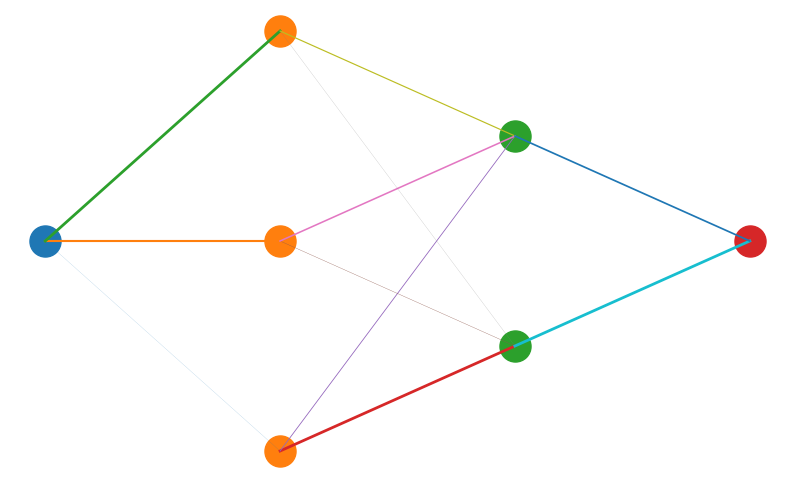

In [61]:
plot_mlp(nn_reg2)

In this visualisation, the width of the connecting edges represents the (magnitude of the) weights between the nodes.

The colours of the nodes here just label the layer.

Remember, this is visualising the actual model you created (and trained) above. You can go back to earlier cells, change the number of nodes per layer, etc., and you should be able to visualise the different networks by rerunning the cells that train the model and then rerunning the cell above that draws the model.

## Architecture, biases and weights

In [62]:
def plot_mlp_weights(model):
    weights = model.coefs_
    biases = model.intercepts_

    # Number of neurons in each layer
    layers = [weights[0].shape[0]] + [W.shape[1] for W in weights]

    fig, ax = plt.subplots(figsize=(14, 8))

    # x position of each layer
    x = np.arange(len(layers))

    # y positions for neurons
    positions = []
    for n in layers:
        positions.append(np.linspace(-(n - 1) / 2, (n - 1) / 2, n))

    # Draw connections and weights
    for l, W in enumerate(weights):

        max_weight = np.max(np.abs(W))

        for i, y1 in enumerate(positions[l]):
            for j, y2 in enumerate(positions[l + 1]):

                weight = W[i, j]

                ax.plot(
                    [x[l], x[l + 1]],
                    [y1, y2],
                    linewidth=2 * abs(weight) / max_weight
                )

                # Weight label
                ax.text(
                    (x[l] + x[l + 1]) / 2,
                    (y1 + y2) / 2,
                    f"{weight:.2f}",
                    fontsize=8,
                    ha="center",
                    va="center"
                )

    # Neurons and biases
    for l, ys in enumerate(positions):

        ax.scatter(
            [x[l]] * len(ys),
            ys,
            s=1150,
            zorder=10
        )

        # Bias label
        for j, y in enumerate(ys):

            ax.text(
                x[l],
                y,
                f"b={biases[l - 1][j]:.2f}" if l > 0 else "",
                fontsize=8,
                ha="center",
                va="center",
                zorder=11
            )

    # Layer labels
    ax.set_xticks(x)
    ax.set_xticklabels(
        ["Input"] +
        [f"Hidden {i}" for i in range(1, len(layers) - 1)] +
        ["Output"]
    )

    ax.axis("off")

    plt.show()

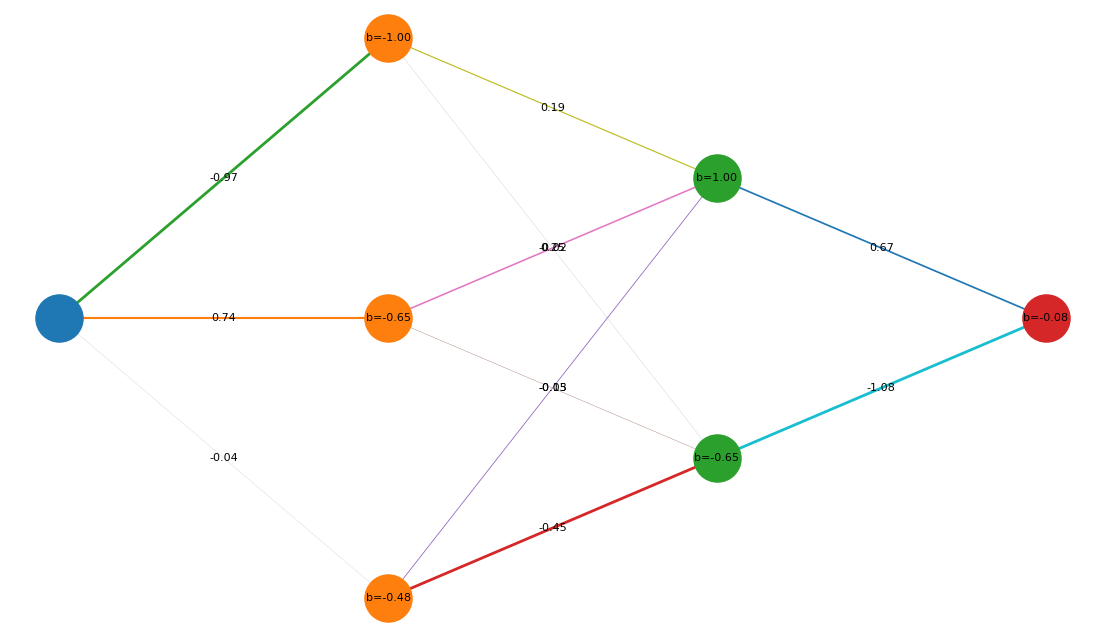

In [63]:
plot_mlp_weights(nn_reg2)

# 3. Neural Networks for classification

We will now see how we can use neural networks in order to perform classification. First, we'll generate a synthetic dataset

In [64]:
X, y = skd.make_moons(n_samples=500, noise=0.3, random_state=1)

Split into train and test sets. We'll use the training set to train the nework and the test set in order to test it's classification performance.

In [65]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.4)

Train MLPClassifier

In [66]:
classifier = MLPClassifier(random_state=1, max_iter=1000)
classifier.fit(X_train, y_train)

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(100,)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",1000
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",1


Evaluate predictions

In [67]:
pred = classifier.predict(X_test)
acc = accuracy_score(y_test, pred)
print(f"\nClassification Accuracy: {acc * 100:.2f}%")


Classification Accuracy: 89.00%


Plot test set predictions vs ground truth

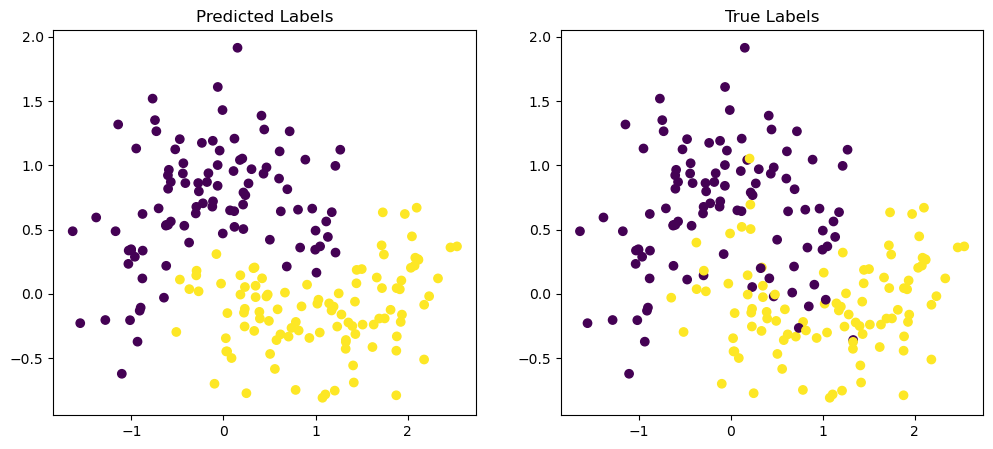

In [68]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(X_test[:, 0], X_test[:, 1], c=pred)
axes[0].set_title("Predicted Labels")

axes[1].scatter(X_test[:, 0], X_test[:, 1], c=y_test)
axes[1].set_title("True Labels")

plt.show()

In [69]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, pred)

array([[88, 13],
       [ 9, 90]])

# Acknowledements & Reuse

This notebook was written by Adam Carter and Ioanna Lampaki, EPCC, The Unviersity of Edinburgh as part of the Pilot - UKAIFA project.

&copy; 2026 The University of Edinburgh

You are welcome to reuse the notebook and its contents under the terms of CC BY 4.0